In [0]:
from pyspark.sql import functions as F
from pyspark.sql.window import Window
import matplotlib.pyplot as plt
import numpy as np
from pyspark.sql import Row

In [0]:
# 1. Load Data
retail_df = spark.table("jarvis_training.default.retail")

# 2. Rename Columns
retail_df = retail_df.withColumnRenamed("Invoice", "invoice_no") \
                     .withColumnRenamed("StockCode", "stock_code") \
                     .withColumnRenamed("Description", "description") \
                     .withColumnRenamed("Quantity", "quantity") \
                     .withColumnRenamed("InvoiceDate", "invoice_date") \
                     .withColumnRenamed("Price", "unit_price") \
                     .withColumnRenamed("Customer ID", "customer_id") \
                     .withColumnRenamed("Country", "country")

# 3. Simple Casting for all columns
retail_df = retail_df.withColumn("invoice_no", F.col("invoice_no").cast("string")) \
                     .withColumn("stock_code", F.col("stock_code").cast("string")) \
                     .withColumn("description", F.col("description").cast("string")) \
                     .withColumn("quantity", F.col("quantity").cast("int")) \
                     .withColumn("invoice_date", F.to_timestamp("invoice_date")) \
                     .withColumn("unit_price", F.col("unit_price").cast("double")) \
                     .withColumn("customer_id", F.col("customer_id").cast("int")) \
                     .withColumn("country", F.col("country").cast("string"))

# 4. Calculations & Formatting
retail_df = retail_df.withColumn("line_item_total", F.col("quantity") * F.col("unit_price"))
retail_df = retail_df.withColumn("invoice_date", F.to_timestamp("invoice_date")) \
                     .withColumn("month_start", F.trunc("invoice_date", "MM")) \
                     .withColumn("year_month", F.date_format("invoice_date", "yyyy-MMM"))

# 5. Verify
retail_df.printSchema()
display(retail_df.limit(10))

root
 |-- invoice_no: string (nullable = true)
 |-- stock_code: string (nullable = true)
 |-- description: string (nullable = true)
 |-- quantity: integer (nullable = true)
 |-- invoice_date: timestamp (nullable = true)
 |-- unit_price: double (nullable = true)
 |-- customer_id: integer (nullable = true)
 |-- country: string (nullable = true)
 |-- line_item_total: double (nullable = true)
 |-- month_start: date (nullable = true)
 |-- year_month: string (nullable = true)



invoice_no,stock_code,description,quantity,invoice_date,unit_price,customer_id,country,line_item_total,month_start,year_month
489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01T07:45:00.000Z,6.95,13085,United Kingdom,83.4,2009-12-01,2009-Dec
489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01T07:45:00.000Z,6.75,13085,United Kingdom,81.0,2009-12-01,2009-Dec
489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01T07:45:00.000Z,6.75,13085,United Kingdom,81.0,2009-12-01,2009-Dec
489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01T07:45:00.000Z,2.1,13085,United Kingdom,100.80000000000001,2009-12-01,2009-Dec
489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01T07:45:00.000Z,1.25,13085,United Kingdom,30.0,2009-12-01,2009-Dec
489434,22064,PINK DOUGHNUT TRINKET POT,24,2009-12-01T07:45:00.000Z,1.65,13085,United Kingdom,39.599999999999994,2009-12-01,2009-Dec
489434,21871,SAVE THE PLANET MUG,24,2009-12-01T07:45:00.000Z,1.25,13085,United Kingdom,30.0,2009-12-01,2009-Dec
489434,21523,FANCY FONT HOME SWEET HOME DOORMAT,10,2009-12-01T07:45:00.000Z,5.95,13085,United Kingdom,59.5,2009-12-01,2009-Dec
489435,22350,CAT BOWL,12,2009-12-01T07:46:00.000Z,2.55,13085,United Kingdom,30.599999999999998,2009-12-01,2009-Dec
489435,22349,"DOG BOWL , CHASING BALL DESIGN",12,2009-12-01T07:46:00.000Z,3.75,13085,United Kingdom,45.0,2009-12-01,2009-Dec


In [0]:

# 4. Calculations & Formatting
retail_df = retail_df.withColumn("line_item_total", F.col("quantity") * F.col("unit_price"))
retail_df = retail_df.withColumn("year_month", F.date_format("invoice_date", "yyyy-MMM"))

# 5. Verify
retail_df.printSchema()
display(retail_df.limit(10))

cancelled_invoices_df = retail_df.filter(F.col("invoice_no").startswith("C"))

# 2. Display the first 10 rows of ONLY the cancellations
display(cancelled_invoices_df.limit(10))

root
 |-- invoice_no: string (nullable = true)
 |-- stock_code: string (nullable = true)
 |-- description: string (nullable = true)
 |-- quantity: integer (nullable = true)
 |-- invoice_date: timestamp (nullable = true)
 |-- unit_price: double (nullable = true)
 |-- customer_id: integer (nullable = true)
 |-- country: string (nullable = true)
 |-- line_item_total: double (nullable = true)
 |-- month_start: date (nullable = true)
 |-- year_month: string (nullable = true)



invoice_no,stock_code,description,quantity,invoice_date,unit_price,customer_id,country,line_item_total,month_start,year_month
489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01T07:45:00.000Z,6.95,13085,United Kingdom,83.4,2009-12-01,2009-Dec
489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01T07:45:00.000Z,6.75,13085,United Kingdom,81.0,2009-12-01,2009-Dec
489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01T07:45:00.000Z,6.75,13085,United Kingdom,81.0,2009-12-01,2009-Dec
489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01T07:45:00.000Z,2.1,13085,United Kingdom,100.80000000000001,2009-12-01,2009-Dec
489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01T07:45:00.000Z,1.25,13085,United Kingdom,30.0,2009-12-01,2009-Dec
489434,22064,PINK DOUGHNUT TRINKET POT,24,2009-12-01T07:45:00.000Z,1.65,13085,United Kingdom,39.599999999999994,2009-12-01,2009-Dec
489434,21871,SAVE THE PLANET MUG,24,2009-12-01T07:45:00.000Z,1.25,13085,United Kingdom,30.0,2009-12-01,2009-Dec
489434,21523,FANCY FONT HOME SWEET HOME DOORMAT,10,2009-12-01T07:45:00.000Z,5.95,13085,United Kingdom,59.5,2009-12-01,2009-Dec
489435,22350,CAT BOWL,12,2009-12-01T07:46:00.000Z,2.55,13085,United Kingdom,30.599999999999998,2009-12-01,2009-Dec
489435,22349,"DOG BOWL , CHASING BALL DESIGN",12,2009-12-01T07:46:00.000Z,3.75,13085,United Kingdom,45.0,2009-12-01,2009-Dec


invoice_no,stock_code,description,quantity,invoice_date,unit_price,customer_id,country,line_item_total,month_start,year_month
C489449,22087,PAPER BUNTING WHITE LACE,-12,2009-12-01T10:33:00.000Z,2.95,16321,Australia,-35.400000000000006,2009-12-01,2009-Dec
C489449,85206A,CREAM FELT EASTER EGG BASKET,-6,2009-12-01T10:33:00.000Z,1.65,16321,Australia,-9.899999999999999,2009-12-01,2009-Dec
C489449,21895,POTTING SHED SOW 'N' GROW SET,-4,2009-12-01T10:33:00.000Z,4.25,16321,Australia,-17.0,2009-12-01,2009-Dec
C489449,21896,POTTING SHED TWINE,-6,2009-12-01T10:33:00.000Z,2.1,16321,Australia,-12.600000000000001,2009-12-01,2009-Dec
C489449,22083,PAPER CHAIN KIT RETRO SPOT,-12,2009-12-01T10:33:00.000Z,2.95,16321,Australia,-35.400000000000006,2009-12-01,2009-Dec
C489449,21871,SAVE THE PLANET MUG,-12,2009-12-01T10:33:00.000Z,1.25,16321,Australia,-15.0,2009-12-01,2009-Dec
C489449,84946,ANTIQUE SILVER TEA GLASS ETCHED,-12,2009-12-01T10:33:00.000Z,1.25,16321,Australia,-15.0,2009-12-01,2009-Dec
C489449,84970S,HANGING HEART ZINC T-LIGHT HOLDER,-24,2009-12-01T10:33:00.000Z,0.85,16321,Australia,-20.4,2009-12-01,2009-Dec
C489449,22090,PAPER BUNTING RETRO SPOTS,-12,2009-12-01T10:33:00.000Z,2.95,16321,Australia,-35.400000000000006,2009-12-01,2009-Dec
C489459,90200A,PURPLE SWEETHEART BRACELET,-3,2009-12-01T10:44:00.000Z,4.25,17592,United Kingdom,-12.75,2009-12-01,2009-Dec


## **Monthly Placed and Canceled Orders**

In [0]:
# 1. Flag cancelled orders (Invoices starting with 'C')
retail_df = retail_df.withColumn("is_cancelled", F.col("invoice_no").startswith("C"))

# 2. Aggregate counts per month
# We use both columns: 'month_start' for chronological sorting and 'year_month' for the label
monthly_df = retail_df.groupBy("month_start", "year_month").agg(
    F.countDistinct("invoice_no").alias("total_orders"),
    F.countDistinct(F.when(F.col("is_cancelled") == True, F.col("invoice_no"))).alias("cancelled_orders")
).orderBy("month_start") 

# 3. Apply your logic: Placed = Total - (2 * Cancelled)
monthly_df = monthly_df.withColumn("placed_orders", 
    F.col("total_orders") - (2 * F.col("cancelled_orders"))
)

# 4. Final Display
# We select only the columns needed for the chart/table
display(monthly_df.select("year_month", "total_orders", "cancelled_orders", "placed_orders").limit(10))

year_month,total_orders,cancelled_orders,placed_orders
2009-Dec,2330,401,1528
2010-Jan,1633,300,1033
2010-Feb,1969,240,1489
2010-Mar,2367,407,1553
2010-Apr,1892,304,1284
2010-May,2418,407,1604
2010-Jun,2216,357,1502
2010-Jul,2017,344,1329
2010-Aug,1877,273,1331
2010-Sep,2375,371,1633


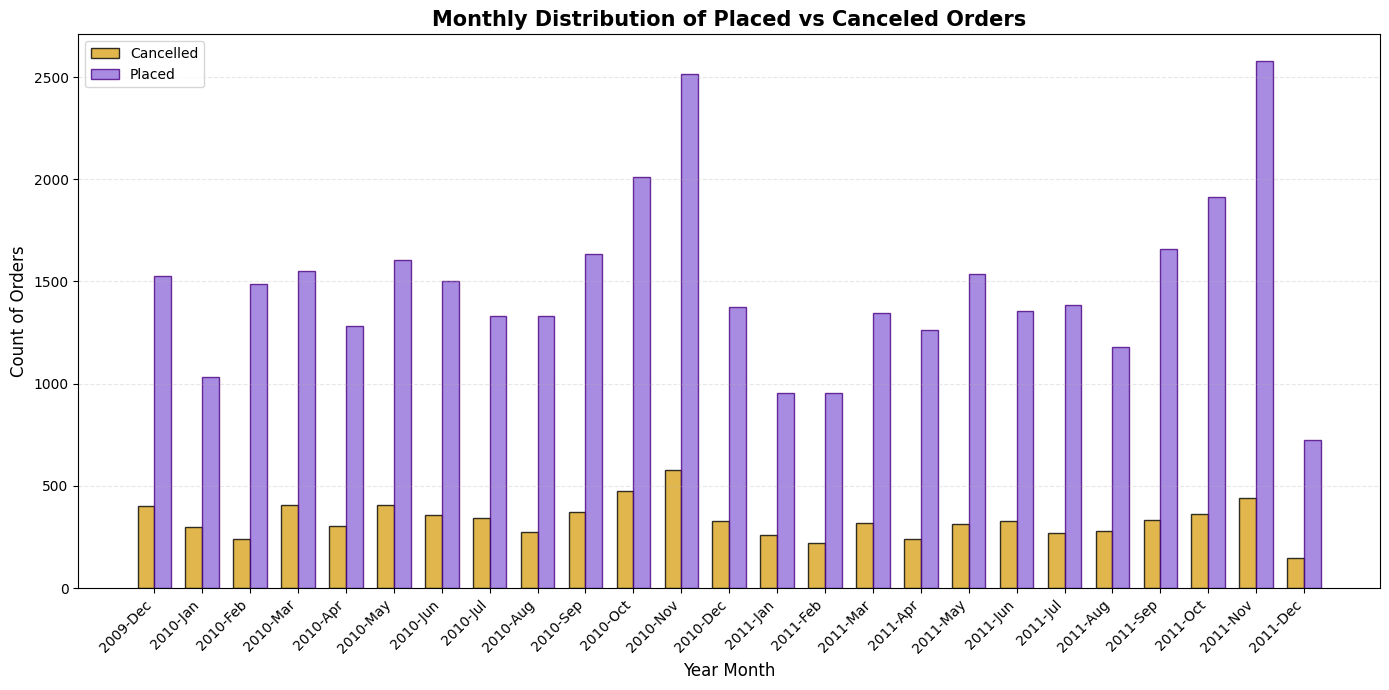

In [0]:
# 1. Simplified: No need to re-format dates here anymore
# 'year_month' is already in your Spark monthly_df as "2011-Jan"

# 2. Bridge to Pandas
pd_monthly = monthly_df.toPandas()

# 3. Set up for grouped bars
labels = pd_monthly['year_month'] # Using your preferred column name
x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(14, 7))

# --- Plotting with your preferred colors (Amber & Purple) ---
ax.bar(x - width/2, pd_monthly['cancelled_orders'], width, 
       label='Cancelled', color='goldenrod', edgecolor='black', alpha=0.8)

ax.bar(x + width/2, pd_monthly['placed_orders'], width, 
       label='Placed', color='mediumpurple', edgecolor='indigo', alpha=0.8)

# 4. Formatting
ax.set_ylabel('Count of Orders', fontsize=12)
ax.set_xlabel('Year Month', fontsize=12)
ax.set_title('Monthly Distribution of Placed vs Canceled Orders', fontsize=15, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45, ha='right')

ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
display(fig)
plt.close(fig)

## **Total Invoice Amount Distribution**

In [0]:
# 1. Calculate line_item_total and 2. Group by Invoice
invoice_df = retail_df.groupBy("invoice_no") \
    .agg(F.sum("line_item_total").alias("invoice_amount"))

# Filter for values higher than 0
invoice_df = invoice_df.filter(F.col("invoice_amount") > 0)

# 3. Calculate Descriptive Statistics
# Spark handles large data, so we aggregate these values together
stats = invoice_df.select(
    F.min("invoice_amount").alias("min"),
    F.max("invoice_amount").alias("max"),
    F.mean("invoice_amount").alias("mean"),
    F.percentile_approx("invoice_amount", 0.5).alias("median")
).collect()[0]

# Calculate Mode (finding the most frequent invoice_amount value)
v_mode = invoice_df.groupBy("invoice_amount").count().orderBy(F.desc("count")).first()[0]

# Extract values for printing
v_min = float(stats['min'])
v_max = float(stats['max'])
v_mean = float(stats['mean'])
v_median = float(stats['median'])
v_mode = float(v_mode)

print(f"Min: {v_min:.2f}")
print(f"Max: {v_max:.2f}")
print(f"Mean: {v_mean:.2f}")
print(f"Median: {v_median:.2f}")
print(f"Mode: {v_mode:.2f}")

# View the result
display(invoice_df.limit(5))

Min: 0.19
Max: 168469.60
Mean: 523.30
Median: 304.30
Mode: 15.00


invoice_no,invoice_amount
489446,996.1
489514,823.02
489519,696.7300000000002
489559,128.60000000000002
489618,6.35


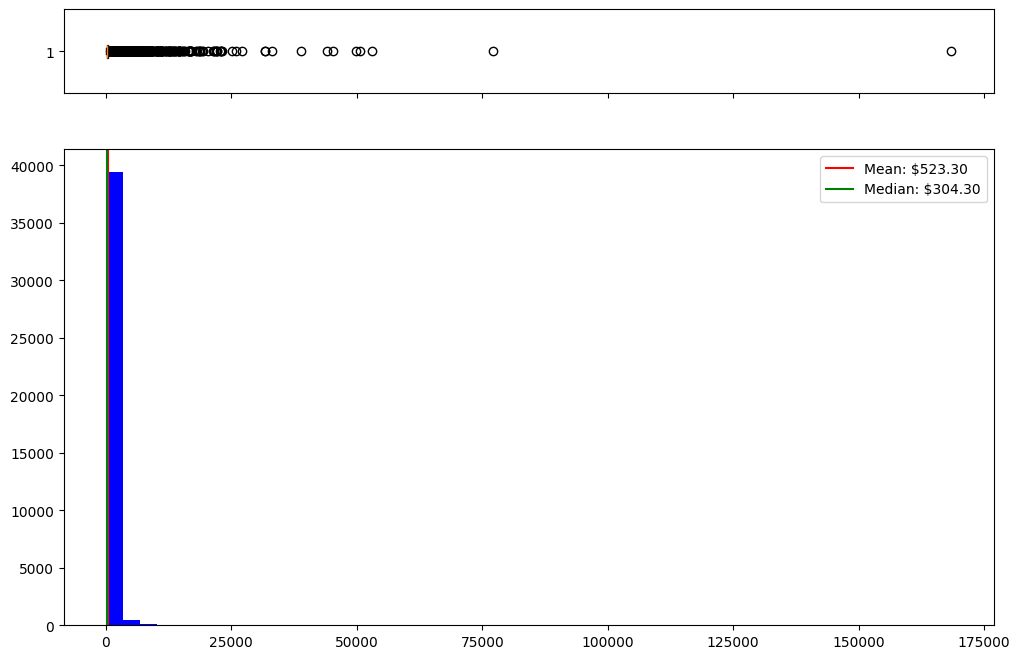

In [0]:
# This moves the processed data from the Spark Cluster to the Local Driver
# This is a necessary step in Databricks for custom Matplotlib charts
pd_series = invoice_df.select("invoice_amount").toPandas()["invoice_amount"]

# This part is standard Python (Matplotlib)
fig, (ax_box, ax_hist) = plt.subplots(2, sharex=True, 
                                      gridspec_kw={"height_ratios": (.15, .85)}, 
                                      figsize=(12, 8))

ax_box.boxplot(pd_series, vert=False, patch_artist=True)
ax_hist.hist(pd_series, bins=50, color='blue')

# Using the PySpark-calculated variables for the lines
ax_hist.axvline(v_mean, color='red', label=f'Mean: ${v_mean:.2f}')
ax_hist.axvline(v_median, color='green', label=f'Median: ${v_median:.2f}')

plt.legend()


min    - $0.19
max    - $724.25
mean   - $271.68
median - $256.20
mode   - $15.00



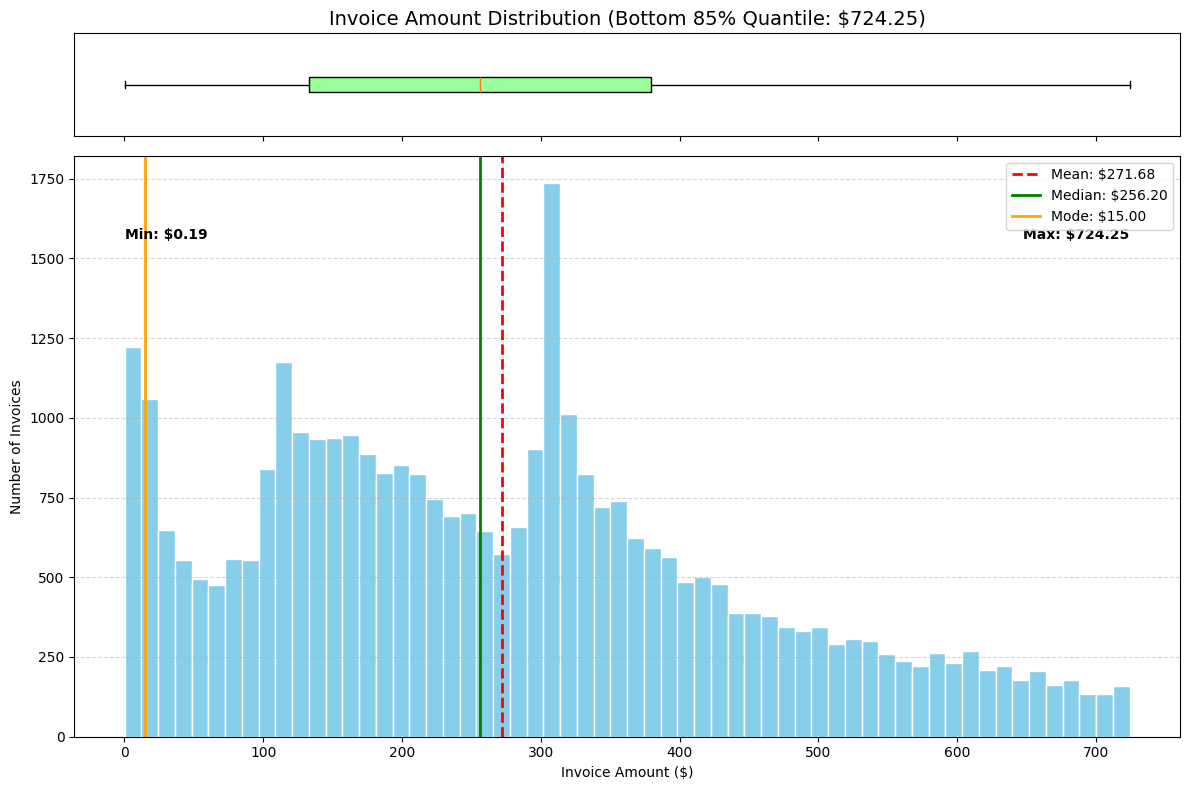

In [0]:
# 1. Calculate the 85th Quantile in Spark
q85 = invoice_df.select(F.percentile_approx("invoice_amount", 0.85)).collect()[0][0]

# 2. Filter the Spark DataFrame to focus on the core 85%
dist_data_df = invoice_df.filter(F.col("invoice_amount") <= q85)

# 3. Calculate Stats for the filtered data in Spark
stats_85 = dist_data_df.select(
    F.min("invoice_amount").alias("min"),
    F.max("invoice_amount").alias("max"),
    F.mean("invoice_amount").alias("mean"),
    F.percentile_approx("invoice_amount", 0.5).alias("median")
).collect()[0]

# Calculate Mode for the filtered data
v_mode_85 = dist_data_df.groupBy("invoice_amount").count().orderBy(F.desc("count")).first()[0]

# Extract scalars for plotting
v_min, v_max = float(stats_85['min']), float(stats_85['max'])
v_mean, v_median = float(stats_85['mean']), float(stats_85['median'])
v_mode = float(v_mode_85)

print(f"""
min    - ${v_min:.2f}
max    - ${v_max:.2f}
mean   - ${v_mean:.2f}
median - ${v_median:.2f}
mode   - ${v_mode:.2f}
""")

# 4. Bridge: Convert only the plotting column to Pandas
pd_series_85 = dist_data_df.select("invoice_amount").toPandas()["invoice_amount"]

# --- VISUALIZATION ---
fig, (ax_box, ax_hist) = plt.subplots(2, sharex=True, 
                                      gridspec_kw={"height_ratios": (.15, .85)}, 
                                      figsize=(12, 8))

# --- Top: Boxplot ---
ax_box.boxplot(pd_series_85, vert=False, patch_artist=True,
               boxprops=dict(facecolor='#99ff99', color='black'))
ax_box.set_title(f'Invoice Amount Distribution (Bottom 85% Quantile: ${q85:.2f})', fontsize=14)
ax_box.set_yticks([])

# --- Bottom: Histogram ---
counts, bins, patches = ax_hist.hist(pd_series_85, bins=60, 
                                     color='skyblue', edgecolor='white')

# Add vertical lines for statistics
ax_hist.axvline(v_mean, color='red', linestyle='--', linewidth=2, label=f'Mean: ${v_mean:.2f}')
ax_hist.axvline(v_median, color='green', linestyle='-', linewidth=2, label=f'Median: ${v_median:.2f}')
ax_hist.axvline(v_mode, color='orange', linestyle='-', linewidth=2, label=f'Mode: ${v_mode:.2f}')

# Annotate Min and Max values on the chart
ax_hist.text(v_min, max(counts)*0.9, f'Min: ${v_min:.2f}', fontweight='bold')
ax_hist.text(v_max, max(counts)*0.9, f'Max: ${v_max:.2f}', fontweight='bold', horizontalalignment='right')

# Formatting
ax_hist.set_xlabel('Invoice Amount ($)')
ax_hist.set_ylabel('Number of Invoices')
ax_hist.legend(loc='upper right')
ax_hist.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()

## **Monthly Net Sales (include cancellations)**

In [0]:
display(retail_df.limit(5))

invoice_no,stock_code,description,quantity,invoice_date,unit_price,customer_id,country,line_item_total,month_start,year_month,is_cancelled
489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01T07:45:00.000Z,6.95,13085,United Kingdom,83.4,2009-12-01,2009-Dec,false
489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01T07:45:00.000Z,6.75,13085,United Kingdom,81.0,2009-12-01,2009-Dec,false
489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01T07:45:00.000Z,6.75,13085,United Kingdom,81.0,2009-12-01,2009-Dec,false
489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01T07:45:00.000Z,2.1,13085,United Kingdom,100.80000000000001,2009-12-01,2009-Dec,false
489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01T07:45:00.000Z,1.25,13085,United Kingdom,30.0,2009-12-01,2009-Dec,false


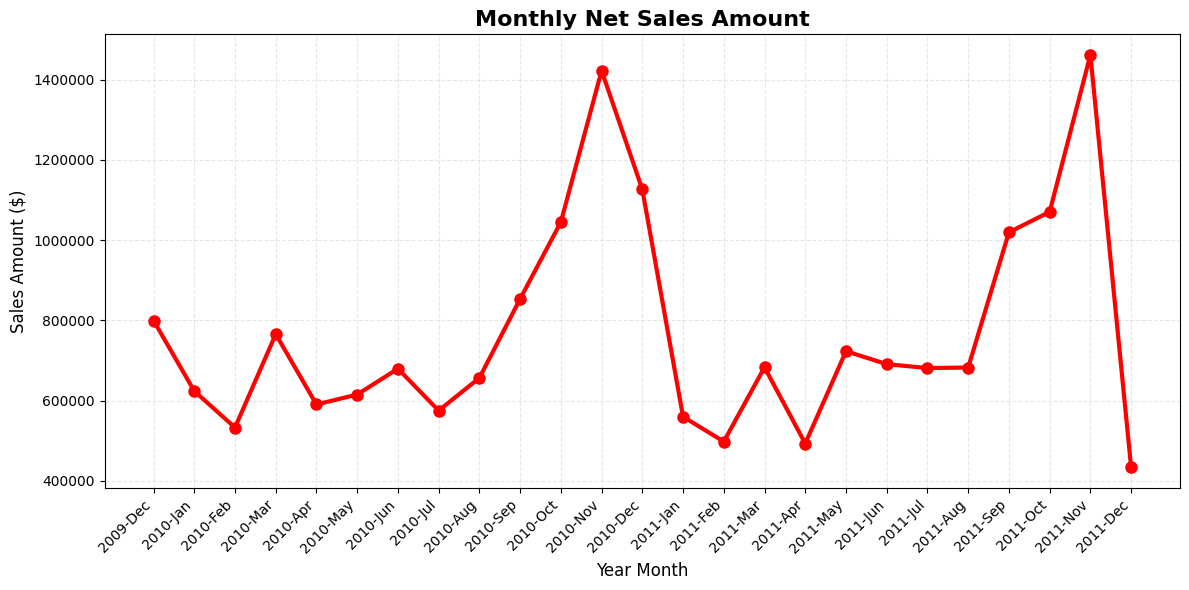

In [0]:
# 1. Aggregate Net Sales Amount
# Use 'month_start' to ensure chronological order and 'year_month' for the chart labels
monthly_sales_df = retail_df.groupBy("month_start", "year_month") \
    .agg(F.sum("line_item_total").alias("total_sales")) \
    .orderBy("month_start")

# 2. Bridge to Pandas
pd_sales = monthly_sales_df.toPandas()

# 3. Visualization
plt.figure(figsize=(12, 6))

# Use the pre-formatted 'year_month' column (e.g., 2011-Jan)
plt.plot(pd_sales['year_month'], pd_sales['total_sales'], 
         marker='o', color='red', linestyle='-', linewidth=3, markersize=8)

# 4. Formatting
plt.title('Monthly Net Sales Amount', fontsize=16, fontweight='bold')
plt.xlabel('Year Month', fontsize=12)
plt.ylabel('Sales Amount ($)', fontsize=12)

plt.xticks(rotation=45, ha='right')
plt.grid(True, linestyle='--', alpha=0.3)

# Format Y-axis to avoid scientific notation
plt.ticklabel_format(style='plain', axis='y') 

plt.tight_layout()
display(plt.gcf())
plt.close()

## **Monthly Net Sales Growth**

/databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/expressions.py:1160: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(


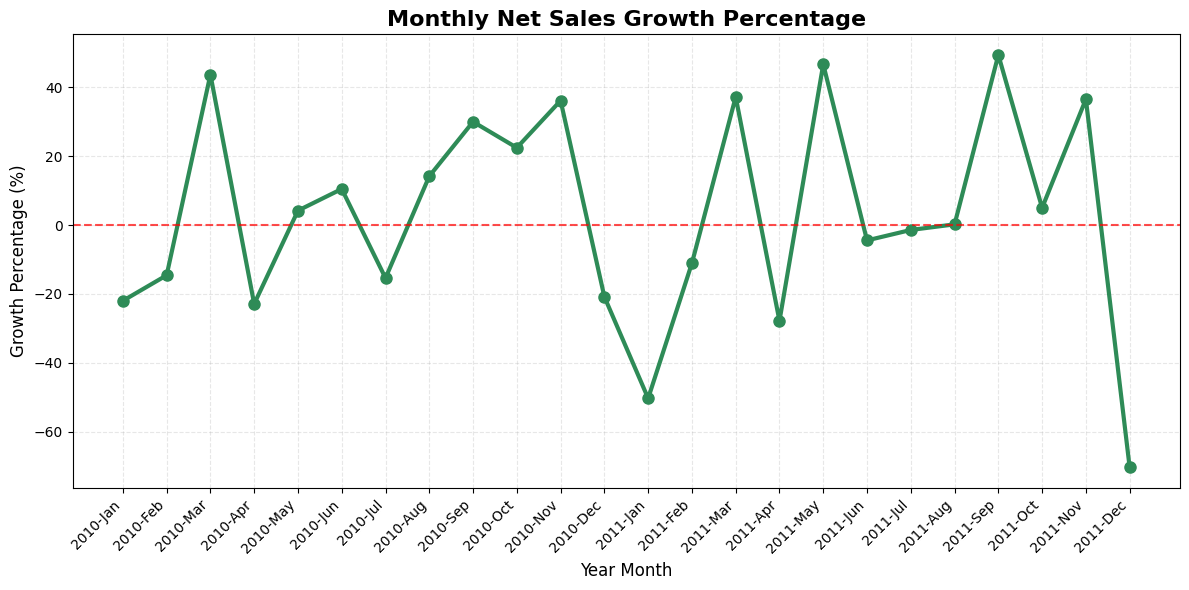

/databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/expressions.py:1160: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(


In [0]:
# 1. Define the Window (ordered by the actual date for accuracy)
window_spec = Window.orderBy("month_start")

# 2. Calculate Growth Percentage
# Using your existing monthly_sales_df columns
monthly_growth_df = monthly_sales_df.withColumn(
    "prev_month_sales", F.lag("total_sales").over(window_spec)
).withColumn(
    "growth_pct", 
    ((F.col("total_sales") - F.col("prev_month_sales")) / F.col("prev_month_sales")) * 100
)

# 3. Bridge to Pandas & Clean NaN
pd_growth = monthly_growth_df.toPandas().dropna(subset=['growth_pct'])

# 4. Visualization
plt.figure(figsize=(12, 6))

# Using your preferred "2011-Jan" format for labels
plt.plot(pd_growth['year_month'], pd_growth['growth_pct'], 
         marker='o', color='seagreen', linestyle='-', linewidth=3, markersize=8)

# 5. Formatting
plt.title('Monthly Net Sales Growth Percentage', fontsize=16, fontweight='bold')
plt.xlabel('Year Month', fontsize=12)
plt.ylabel('Growth Percentage (%)', fontsize=12)

plt.axhline(0, color='red', linestyle='--', linewidth=1.5, alpha=0.7)
plt.xticks(rotation=45, ha='right')
plt.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
display(plt.gcf())
plt.close()

## **Monthly Active Users**

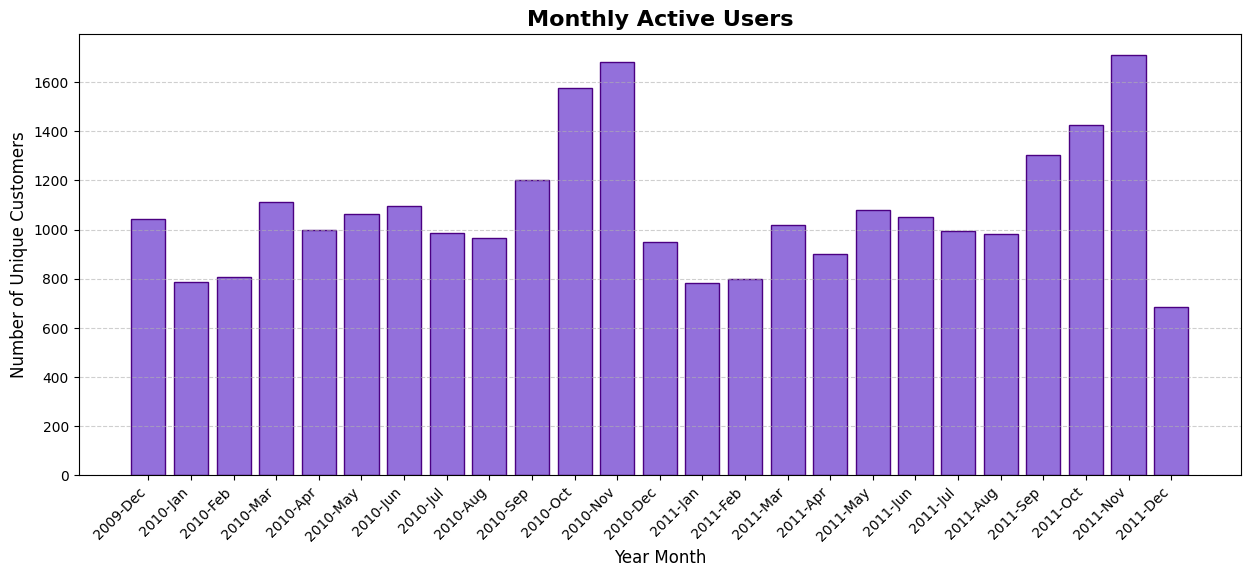

In [0]:
# 1. Data Aggregation in Spark
# We group by both to ensure chronological sorting via month_start
active_users_df = retail_df.groupBy("month_start", "year_month").agg(
    F.countDistinct("customer_id").alias("active_customer_count")
).orderBy("month_start")

# 2. Bridge to Pandas for Visualization
active_users = active_users_df.toPandas()

# 3. Plotting
# Using a wider figure to prevent crowding as per your original code
fig, ax = plt.subplots(figsize=(15, 7))

# Using your preferred Purple/Indigo theme instead of skyblue
ax.bar(active_users['year_month'], active_users['active_customer_count'], 
       color='mediumpurple', edgecolor='indigo', width=0.8)

# 4. Text & Labels
ax.set_title('Monthly Active Users', fontsize=16, fontweight='bold')
ax.set_xlabel('Year Month', fontsize=12) # Updated label
ax.set_ylabel('Number of Unique Customers', fontsize=12)

# 5. Formatting
# ha='right' and rotation ensures labels don't bleed off the edge
plt.xticks(rotation=45, ha='right')

# Manual Margin Control
# This forces the plot to leave 25% of the bottom space empty for your labels
plt.subplots_adjust(bottom=0.25) 
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.show()

## **Monthly Net Sales VS Active User Count**

/home/spark-6786bd0a-3ca3-473b-b641-10/.ipykernel/1882/command-6193651694045222-597164588:31: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(pd_combined['year_month'], rotation=45, ha='right', rotation_mode='anchor', fontsize=10)


hi


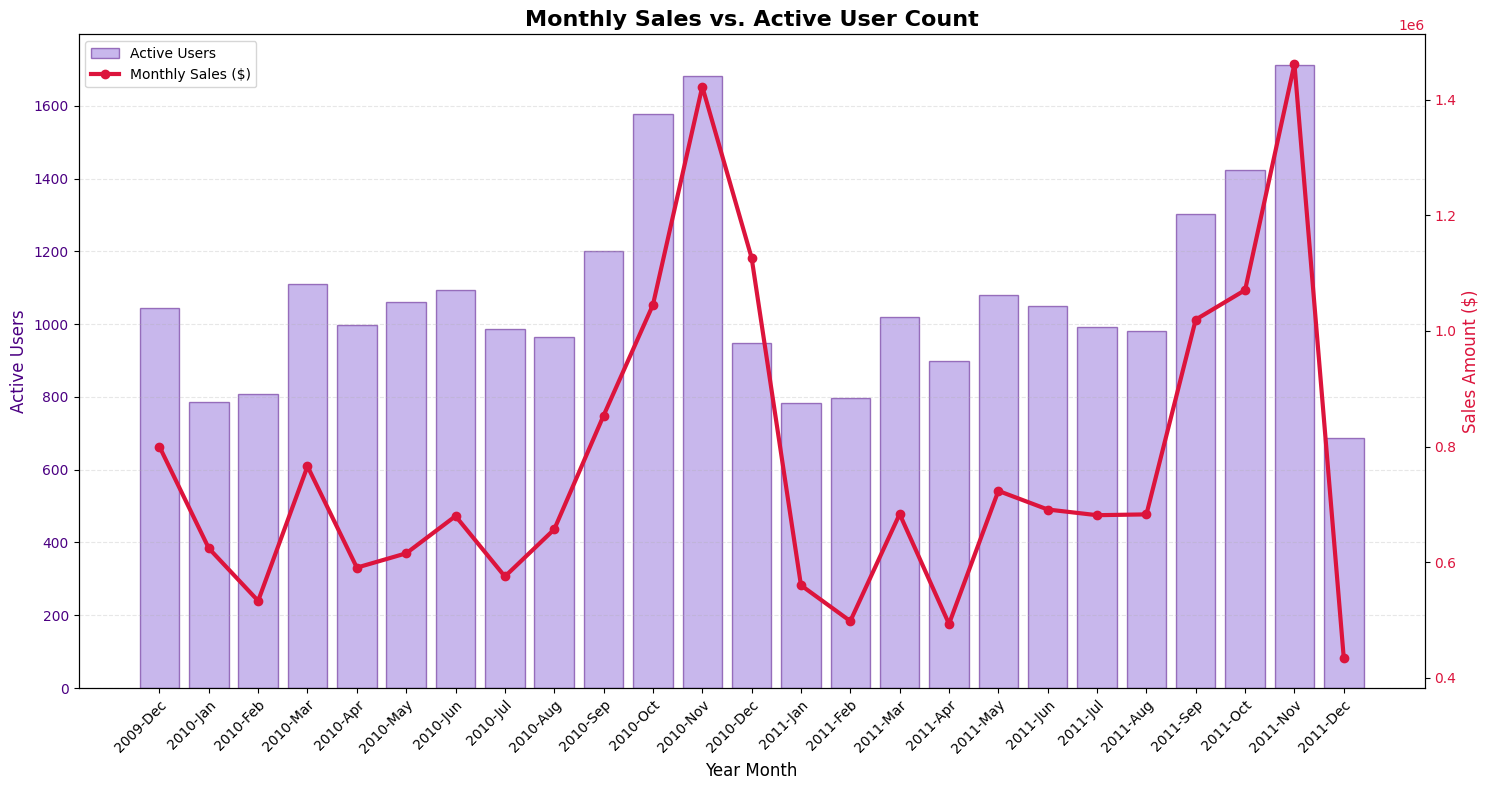

In [0]:
# 1. Join using both columns to avoid duplicates and preserve sorting logic
# Using a list ['col1', 'col2'] prevents the "Duplicate Column" error in toPandas()
combined_df = monthly_sales_df.join(active_users_df, ["year_month", "month_start"]) \
    .orderBy("month_start")

# 2. Bridge to Pandas
pd_combined = combined_df.toPandas()

# 3. Visualization
fig, ax1 = plt.subplots(figsize=(15, 8))

# --- Plot 1: Monthly Active Users (Bars) ---
ax1.set_xlabel('Year Month', fontsize=12)
ax1.set_ylabel('Active Users', color='indigo', fontsize=12)
ax1.bar(pd_combined['year_month'], pd_combined['active_customer_count'], 
        color='mediumpurple', alpha=0.5, edgecolor='indigo', label='Active Users')
ax1.tick_params(axis='y', labelcolor='indigo')

# --- Plot 2: Monthly Net Sales Amount (Line) ---
ax2 = ax1.twinx() 
ax2.set_ylabel('Sales Amount ($)', color='crimson', fontsize=12)
ax2.plot(pd_combined['year_month'], pd_combined['total_sales'], 
         color='crimson', marker='o', linewidth=3, label='Monthly Sales ($)')
ax2.tick_params(axis='y', labelcolor='crimson')

# 4. Formatting
ax1.set_title('Monthly Sales vs. Active User Count', fontsize=16, fontweight='bold')
ax1.grid(axis='y', linestyle='--', alpha=0.3)

# Apply rotation directly to the ax1 object
ax1.set_xticklabels(pd_combined['year_month'], rotation=45, ha='right', rotation_mode='anchor', fontsize=10)

# Combine legends properly
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
print("hi")
plt.tight_layout()
display(fig)
plt.close(fig)

## **TOP 40 PRODUCTS BY QUANTITY SOLD(9.96% of net revenue)**


In [0]:
# We filter out all 'C' invoices once at the start
net_df = retail_df.withColumn("line_total", F.col("quantity") * F.col("unit_price"))

# STEP 2: Find the Top 40 Items (By Quantity)
top_40_df = net_df.groupBy("description") \
    .agg(F.sum("quantity").alias("total_qty"),
         F.sum("line_total").alias("item_revenue")) \
    .orderBy(F.desc("total_qty")) \
    .limit(40)

# STEP 3: Calculate the Revenue Percentage
total_company_revenue = net_df.select(F.sum("line_total")).collect()[0][0]
top_40_total_revenue = top_40_df.select(F.sum("item_revenue")).collect()[0][0]
contribution_pct = (top_40_total_revenue / total_company_revenue) * 100

# STEP 4: Display the Summary Table
summary_table = [
    Row(Metric="Total Net Revenue", Value=f"${total_company_revenue:,.2f}"),
    Row(Metric="Top 40 Products Net Revenue", Value=f"${top_40_total_revenue:,.2f}"),
    Row(Metric="Revenue Contribution (%)", Value=f"{contribution_pct:.2f}%")
]
display(spark.createDataFrame(summary_table))

Metric,Value
Total Net Revenue,"$19,287,250.47"
Top 40 Products Net Revenue,"$1,920,544.78"
Revenue Contribution (%),9.96%


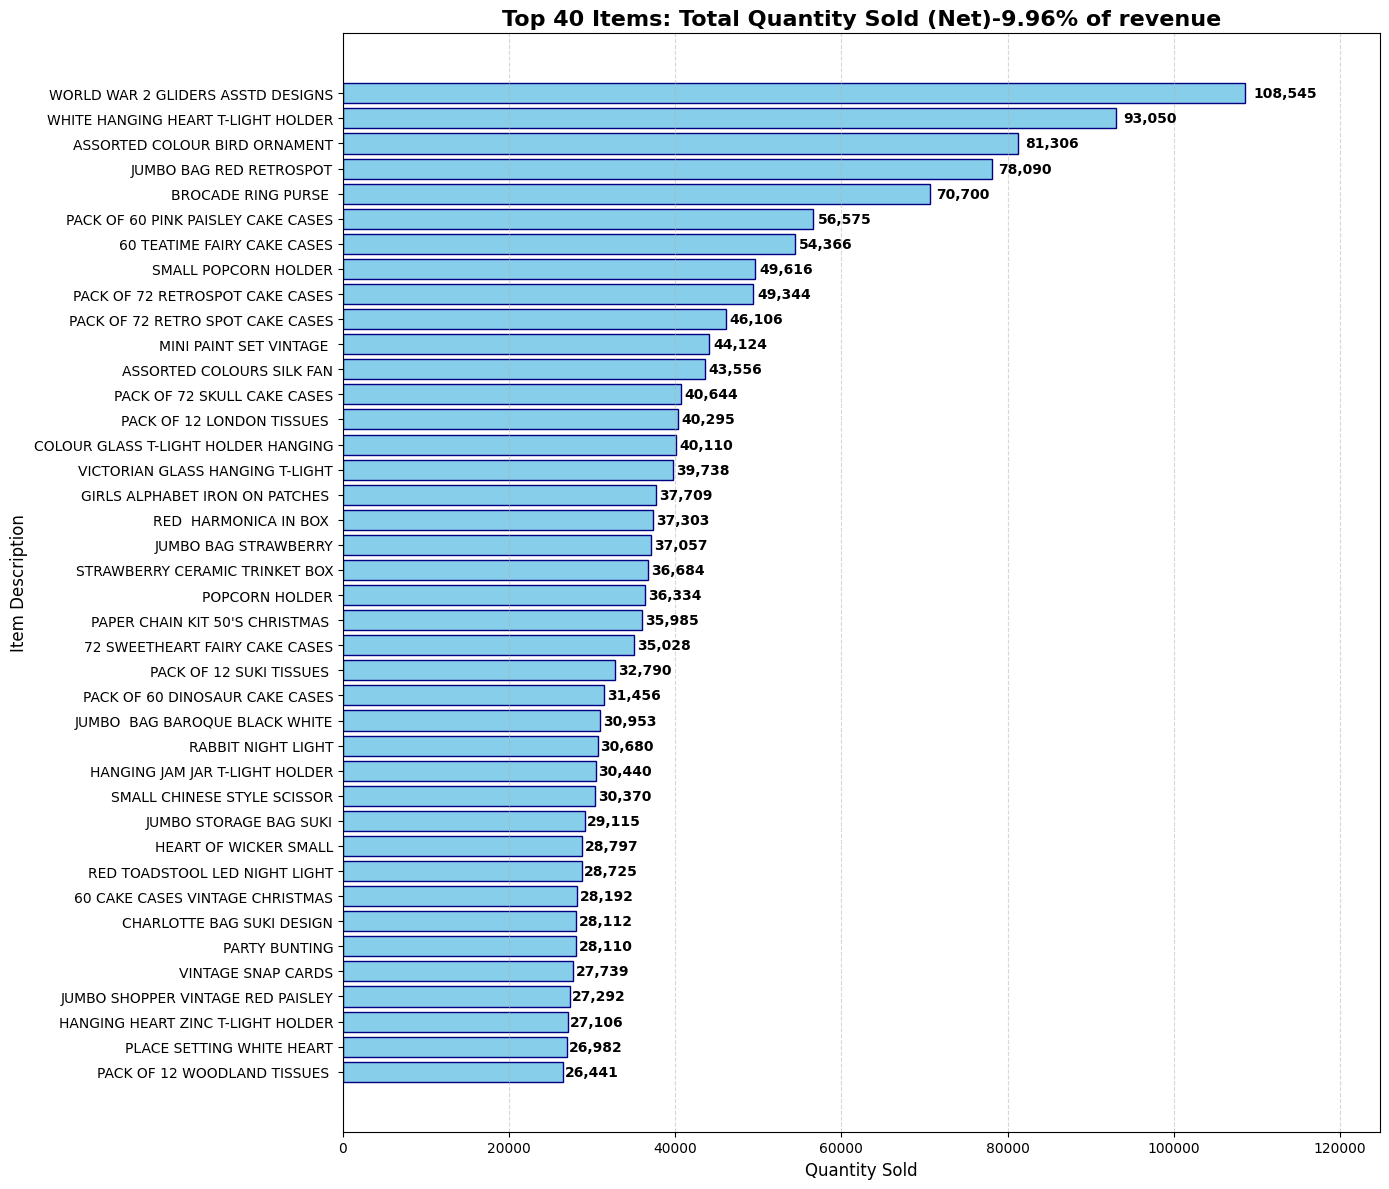

In [0]:
# 1. Filter and Aggregate
# We remove 'C' invoices (cancellations) to get Gross Sales numbers
top_40_sold_df = retail_df.groupBy("description") \
    .agg(F.sum("quantity").alias("total_qty")) \
    .orderBy(F.desc("total_qty")) \
    .limit(40)

# 2. Convert to Pandas for plotting
pd_top_40 = top_40_sold_df.toPandas()

# 3. Visualization
fig, ax = plt.subplots(figsize=(14, 12))
bars = ax.barh(pd_top_40['description'], pd_top_40['total_qty'], 
               color='skyblue', edgecolor='navy')

# 4. Add the "Nos" (Data Labels) to each bar
# We loop through each bar and place the value at the end of it
for bar in bars:
    width = bar.get_width()
    ax.text(width + (width * 0.01),      # X-position (slightly past the bar)
            bar.get_y() + bar.get_height()/2, # Y-position (centered in bar)
            f'{int(width):,}',           # The text (formatted with commas)
            va='center', fontsize=10, fontweight='bold')

# 5. Final Formatting
ax.set_title('Top 40 Items: Total Quantity Sold (Net)-9.96% of revenue', fontsize=16, fontweight='bold')
ax.set_xlabel('Quantity Sold', fontsize=12)
ax.set_ylabel('Item Description', fontsize=12)
ax.invert_yaxis()  # Best seller at the top
ax.grid(axis='x', linestyle='--', alpha=0.5)

# Add extra padding to the right so labels don't get cut off
ax.set_xlim(0, pd_top_40['total_qty'].max() * 1.15)

plt.tight_layout()
display(fig)
plt.close(fig)

In [0]:
# 1. Clean the data to match your Pandas logic
# Filter out non-positive quantities and prices upfront
anchor_date = F.lit("2012-01-01").cast("timestamp")
df_cleaned = retail_df.filter(
    (F.col("customer_id").isNotNull()) & 
    (F.col("quantity") > 0) & 
    (F.col("unit_price") > 0)
)


# 3. Calculate RFM
rfm_table = df_cleaned.groupBy("customer_id").agg(
    F.datediff(anchor_date, F.max("invoice_date")).alias("Recency"),
    F.countDistinct("invoice_no").alias("Frequency"),
    F.sum("line_item_total").alias("Monetary")
)

display(rfm_table.orderBy("customer_id"))

customer_id,Recency,Frequency,Monetary
12346,348,12,77556.46
12347,25,8,5633.32
12348,98,5,2019.4
12349,41,4,4428.69
12350,333,1,334.40000000000003
12351,398,1,300.93
12352,59,10,2849.8399999999997
12353,227,2,406.75999999999993
12354,255,1,1079.4
12355,237,2,947.6099999999999


In [0]:
w_rec = Window.orderBy(F.col("Recency").desc())
w_freq = Window.orderBy(F.col("Frequency").asc())
w_mon = Window.orderBy(F.col("Monetary").asc())

# 2. Apply ntile(5) directly
# By not using a global partition, Spark can process this much faster.
rfm_table_with_scores = rfm_table \
    .withColumn("RecencyScore", F.ntile(5).over(w_rec)) \
    .withColumn("FrequencyScore", F.ntile(5).over(w_freq)) \
    .withColumn("MonetaryScore", F.ntile(5).over(w_mon))

# 3. Create the combined RFM_SCORE string
rfm_final = rfm_table_with_scores.withColumn(
    "RFM_SCORE", 
    F.concat(
        F.col("RecencyScore").cast("string"), 
        F.col("FrequencyScore").cast("string"), 
        F.col("MonetaryScore").cast("string")
    )
)

# 4. Display result
display(rfm_final.orderBy("customer_id").limit(15))

/databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/expressions.py:1160: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(


customer_id,Recency,Frequency,Monetary,RecencyScore,FrequencyScore,MonetaryScore,RFM_SCORE
12346,348,12,77556.46,2,5,5,255
12347,25,8,5633.32,5,5,5,555
12348,98,5,2019.4,3,4,4,344
12349,41,4,4428.69,5,4,5,545
12350,333,1,334.40000000000003,2,1,2,212
12351,398,1,300.93,2,1,2,212
12352,59,10,2849.8399999999997,4,5,4,454
12353,227,2,406.75999999999993,2,2,2,222
12354,255,1,1079.4,2,1,3,213
12355,237,2,947.6099999999999,2,2,3,223


In [0]:
# 1. Use the DataFrame that actually contains the Score columns
# If you used 'rfm_table_with_scores' in the last cell, use it here:
rfm_segmented = rfm_final.withColumn(
    "SegmentCode", 
    F.concat(F.col("RecencyScore").cast("string"), F.col("FrequencyScore").cast("string"))
)

# 2. Apply the mapping
rfm_final = rfm_segmented.withColumn("Segment", 
    F.when(F.col("SegmentCode").rlike("^[1-2][1-2]"), "Hibernating")
     .when(F.col("SegmentCode").rlike("^[1-2][3-4]"), "At Risk")
     .when(F.col("SegmentCode").rlike("^[1-2]5"), "Can't Lose")
     .when(F.col("SegmentCode").rlike("^3[1-2]"), "About to Sleep")
     .when(F.col("SegmentCode").rlike("^33"), "Need Attention")
     .when(F.col("SegmentCode").rlike("^[3-4][4-5]"), "Loyal Customers")
     .when(F.col("SegmentCode").rlike("^41"), "Promising")
     .when(F.col("SegmentCode").rlike("^51"), "New Customers")
     .when(F.col("SegmentCode").rlike("^[4-5][2-3]"), "Potential Loyalists")
     .when(F.col("SegmentCode").rlike("^5[4-5]"), "Champions")
     .otherwise("Unknown")
)

# 3. Final Display
display(rfm_final.limit(15))

/databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/expressions.py:1160: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(


customer_id,Recency,Frequency,Monetary,RecencyScore,FrequencyScore,MonetaryScore,RFM_SCORE,SegmentCode,Segment
14095,745,1,2.95,1,1,1,111,11,Hibernating
13788,528,1,3.75,1,1,1,111,11,Hibernating
16738,320,1,3.75,2,1,1,211,21,Hibernating
14792,86,1,6.2,3,2,1,321,32,About to Sleep
15913,557,1,6.300000000000001,1,1,1,111,11,Hibernating
15040,564,1,7.49,1,1,1,111,11,Hibernating
18115,720,1,9.7,1,1,1,111,11,Hibernating
17378,397,1,10.95,2,1,1,211,21,Hibernating
17956,272,1,12.75,2,1,1,211,21,Hibernating
16878,107,1,13.3,3,2,1,321,32,About to Sleep
